In [ ]:
import numpy as np

import matplotlib.pyplot as plt

import time
from test_rig_control_model.ewcmde import EWCMDESystem

import pandas as pd


# Simulation Setup

In [3]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

In [4]:
## average operating conditions
# volume flow
q_mean = 0.0001281  # m^3/2
# pump speed
omega_mean = 41.6667  # Hz
omega_max = 74.166667
omega_mean_relative = omega_mean / 74.166667  # dimensionless
mean_pump_pressure = 25693.388992199867
tank_mean_pressure = 1093.4335210593865 / (rho * g)

In [5]:
internal_nodes = {
    "pump_inlet": {
        "name": "pump_inlet",
        "node_type": "Junction",
        "elevation": 0.33,
        "demand": 0,
    },
    "pump_outlet": {
        "name": "pump_outlet",
        "node_type": "Junction",
        "elevation": 0.47,
        "demand": 0,
    },
    "tank_inlet": {
        "name": "tank_inlet",
        "node_type": "Tank",
        "elevation": 2.12,
        "area": 1e3,
        "initial_level": 0.0,
        "max_level": 100,
        "demand": 0.000,
    },
    "tank_outlet": {
        "name": "tank_outlet",
        "node_type": "Tank",
        "elevation": 1.2,
        "area": np.pi * 0.18**2 / 4,
        "initial_level": 0.2,
        "max_level": 2,
        "demand": 0.000,
    },
    "consumer_valve_inlet": {
        "name": "consumer_valve_inlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_valve_outlet": {
        "name": "consumer_valve_outlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
}


reservoirs = {
    "reservoir_1": {
        "name": "reservoir_1",
        "elevation": 0.513,
        "pressure": 0.22 - 0.182,
    },
    "reservoir_2": {
        "name": "reservoir_2",
        "elevation": 0.513,
        "pressure": 0.3833,
    },
}


pipes = {
    "pump_suction_pipe": {
        "start_node": "reservoir_1",
        "end_node": "pump_inlet",
        "type": "pipe",
        "length": 2.25,
        "diameter": 0.015,
        "roughness": 0.10367,
    },
    "tank_feeding_pipe": {
        "start_node": "pump_outlet",
        "end_node": "tank_inlet",
        "type": "pipe",
        "length": 5,
        "diameter": 0.015,
        "roughness": 0.10367,
    },
    "tank_outlet_pipe": {
        "start_node": "tank_outlet",
        "end_node": "consumer_valve_inlet",
        "type": "pipe",
        "length": 1.7,
        "diameter": 0.015,
        "roughness": 0.10367,
    },
    "consumer_outlet_pipe": {
        "start_node": "consumer_valve_outlet",
        "end_node": "reservoir_2",
        "type": "pipe",
        "length": 0.35,
        "diameter": 0.015,
        "roughness": 0.10367,
    },
}

virtual_pipes = {
    "tank_connecting_pipe": {
        "start_node": "tank_inlet",
        "end_node": "tank_outlet",
        "type": "pipe",
        "length": 1,
        "diameter": 0.015,
        "roughness": 0.02,
        "friction_factor": 4.4e-3,
    },
}

pumps = {
    "pump": {
        "start_node": "pump_inlet",
        "end_node": "pump_outlet",
        "type": "pump",
        "diameter": 0.015,
        "length": 0.1,
        "head_coefficients": [
            1.0,
            57.53767864,
            0.06786107,
        ],
        "power_coefficients": [
            -3.24482049,
            7.30651404,
            20.33482845,
            103.00866719,
            7.59352180888483,
        ],
        "system_coefficient": 0.3,
        "min_speed": 23.33333,
        "max_speed": 74.16667,
        "initial_input": omega_mean,
    }
}

valves = {
    "consumer_valve": {
        "start_node": "consumer_valve_inlet",
        "end_node": "consumer_valve_outlet",
        "type": "valve",
        "diameter": 0.015,
        "length": 0.1,
        "system_coefficient": 1 / 1.274597418793966,
        "valve_coefficient": 0.5,
        "initial_input": 0.753,
    },
}

In [6]:
q_p_0 = {
    "pump_suction_pipe": q_mean,
    "tank_feeding_pipe": q_mean,
    "tank_outlet_pipe": q_mean,
    "consumer_outlet_pipe": q_mean,
}
h_I_0 = {
    "pump_inlet": 0.333,
    "pump_outlet": 0.467,
    "tank_inlet": 2.353,
    "tank_outlet": 1.2 + tank_mean_pressure,
    "consumer_valve_inlet": 0.875,
    "consumer_valve_outlet": 0.875,
}
z_0 = {
    "pump": omega_mean,
    "consumer_valve": 0.753,
}

q_e_0 = {
    "tank_connecting_pipe": q_mean,
    "pump": q_mean,
    "consumer_valve": q_mean,
}

# Simulation run

In [7]:
sys = EWCMDESystem()
sys.construct_from_json(
    internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves, g, a
)
sys.set_up_DAE()
sys.set_up_initial_values(q_p_0, h_I_0, z_0, q_e_0)

t0 = 0
t_stop = 1800
dt = 1e-2
nt = round((t_stop - t0) / dt)

t_3 = np.arange(t0, t_stop, dt)

u_h_R = (
    np.diag([r["elevation"] + r["pressure"] for r in reservoirs.values()])
    @ np.ones((len(reservoirs), nt))
).T

u_Q = (
    np.diag([node["demand"] for node in internal_nodes.values()])
    @ np.ones((len(internal_nodes), nt))
).T

u_u_e = (
    np.diag([el["initial_input"] for el in sys.elements.values()])
    @ np.ones((len(sys.elements.values()), nt))
).T

u = np.concatenate([u_h_R, u_Q, u_u_e], axis=1)

start = time.time()
x_vals_3, ax_vals_3 = sys.simulate_state(u, t0=t0, t_stop=t_stop, dt=dt)
end = time.time()
time_elapsed_3 = end - start

## Plot results

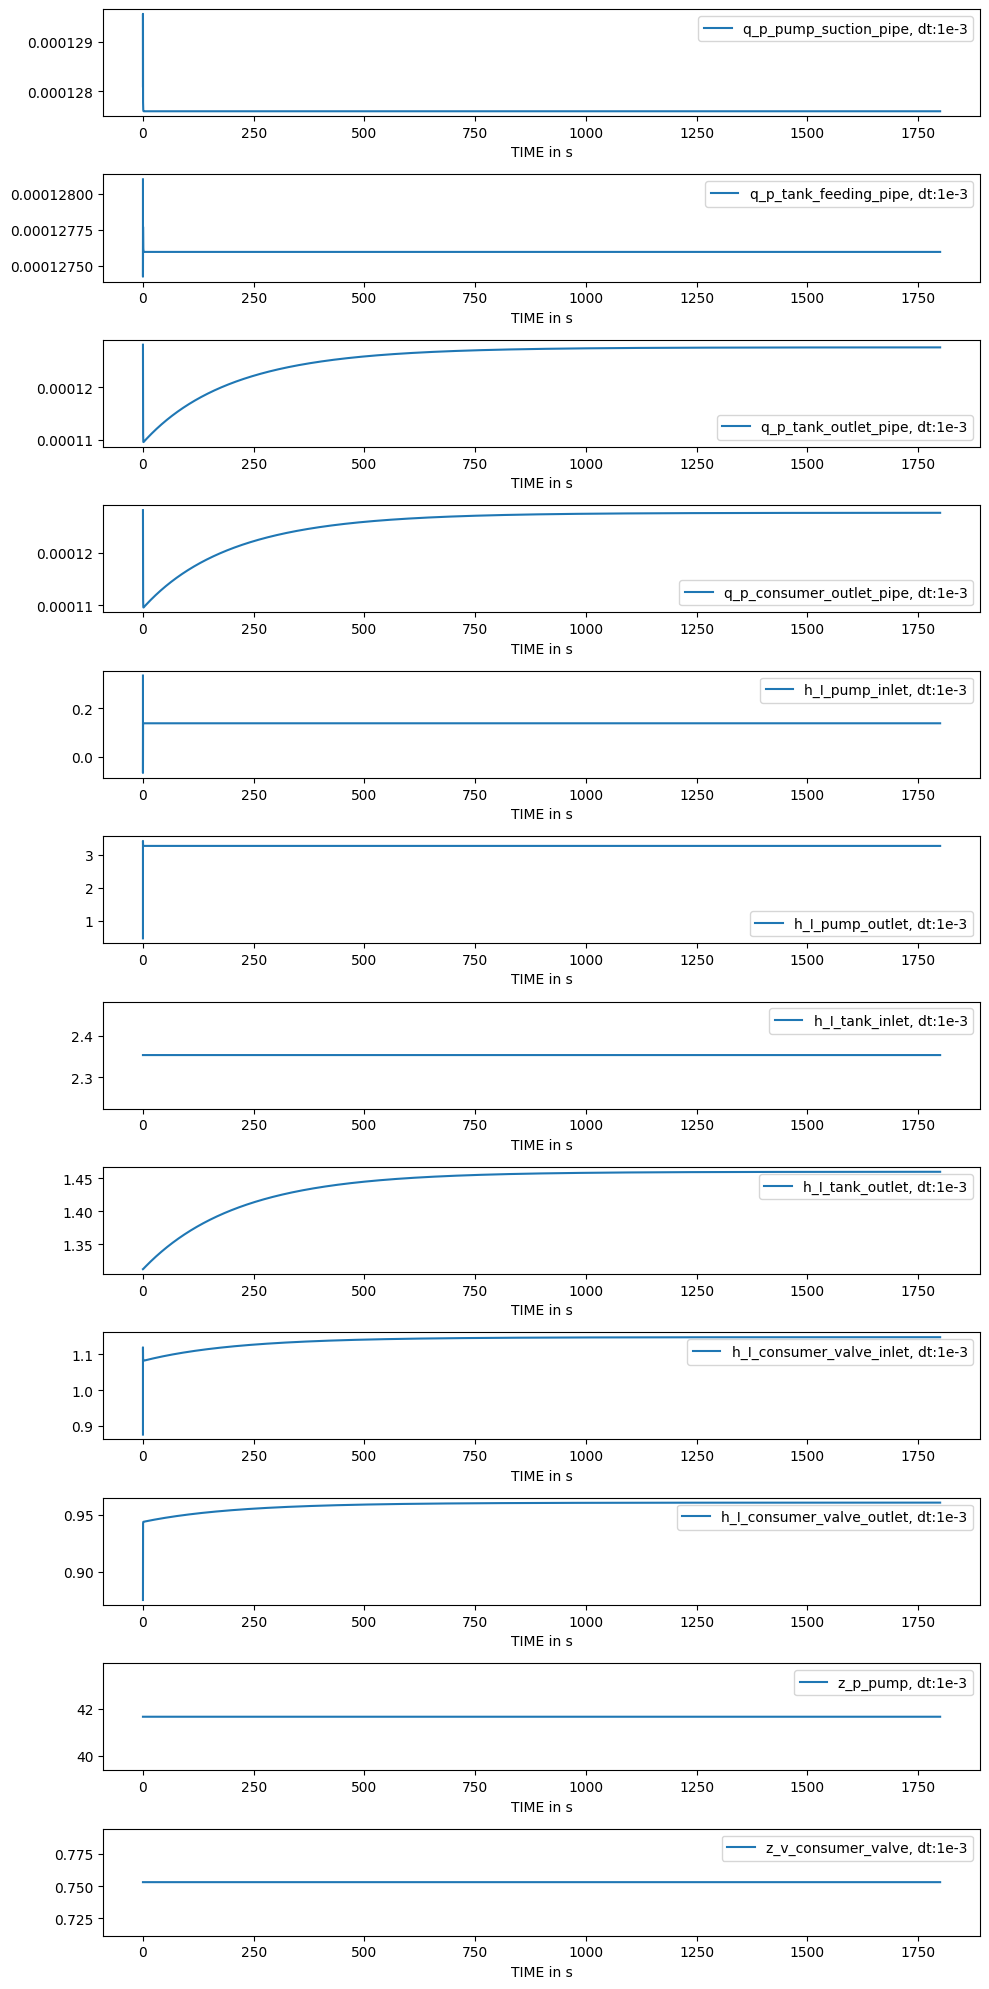

In [8]:
fig, axs = plt.subplots(sys.x.shape[0], figsize=(10, 20))
t = np.arange(t0, t_stop, dt)

for i in range(sys.x.shape[0]):
    axs[i].plot(t_3[:], x_vals_3[:, i], label=sys.x[i].name() + ", dt:1e-3")
    axs[i].legend()
    axs[i].set_xlabel("TIME in s")

fig.tight_layout()

## Save results

In [9]:
x_names = [sys.x[i].name() for i in range(sys.x.numel())]
df = pd.DataFrame(
    np.hstack([x_vals_3, t_3.reshape(len(t_3), 1)]), columns=x_names + ["time"]
)
df.to_hdf("../data/constant_operating_point_4167_75.hdf5", "df", mode="w")

C:\Users\Lestakova\AppData\Local\Temp\ipykernel_9908\2559802686.py:5: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf("../data/constant_operating_point_4167_75.hdf5", "df", mode="w")
